In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import scipy
import matplotlib.pyplot as plt
import os

from model import *

In [2]:
class PlaceCells1D(object):

    def __init__(self, options):
        self.Np = options.Np
        self.track_length = options.track_length
        self.sigma = options.place_cell_rf
        self.seed = options.plce_cell_seed
        self.device = options.device
        self.periodic = options.periodic

        # Randomly initialize place cell centers: 1d array of shape [Np].
        np.random.seed(self.seed)
        # self.centers = torch.tensor(np.random.uniform(-self.track_length/2, self.track_length/2, self.Np))
        self.centers = torch.tensor(np.linspace(-self.track_length/2, self.track_length/2, self.Np))
        self.centers = self.centers.to(self.device)

    def get_activation(self, pos):
        '''
        Get the activation of the place cells given the position of the agent

        Inputs:
            pos: (batch_size, seq_len, 1) tensor of the position of the agent

        Outputs:
            activation: (batch_size, seq_len, Np) tensor of the activation of the place cells
        '''

        # Compute distance between position and place cell centers: [batch_size, sequence_length, Np].
        d = torch.abs(pos[:, :, None, :] - self.centers[None, None, :, None]).float().squeeze(-1)
        if self.periodic:
            d = torch.min(d, self.track_length - d)

        if self.sigma is not None:
            # use gaussian activation
            activation = torch.exp(-d**2 / (2 * self.sigma**2))
        else:
            # use one hot encoding
            min_vals, _ = torch.min(d, dim=-1, keepdim=True)
            activation = (d == min_vals).float()

        return activation

    def get_nearest_cell_pos(self, activation, k=3):
        '''
        Decode position using centers of k maximally active place cells.
        
        Args: 
            activation: Place cell activations of shape [batch_size, sequence_length, Np].
            k: Number of maximally active place cells with which to decode position.

        Returns:
            pred_pos: Predicted 2d position with shape [batch_size, sequence_length, 1].
        '''
        # top-k place cells along the last dimension; idx: [batch_size, sequence_length, k]
        _, idxs = torch.topk(activation, k=k)
        # centers[idxs] will slice the centers along the last dimension using the indices in idxs: [batch_size, sequence_length, k]
        pred_pos = self.centers[idxs].mean(-1, keepdim=True)
        return pred_pos

In [3]:
class TrajectoryGenerator1D(object):

    def __init__(self, options, place_cell):
        self.options = options
        self.place_cell = place_cell

    def avoid_wall(self, position):
        '''
        Avoid the wall by reflecting the position when the agent hits the wall

        Inputs:
            position: (batch_size) tensor of the CURRENT position of the agent
            dt: float, time step

        Outputs:
            position: (batch_size) tensor of the position of the agent after reflection
        '''
        track_length = self.place_cell.track_length
        dt = self.options.dt
        # check if the agent hits the wall
        hit_wall = (position.abs() >= track_length / 2)
        # if the agent hits the wall, current position should be border - the amount of overshoot
        sign = torch.sign(position[hit_wall])
        position[hit_wall] = sign * track_length / 2 - (position[hit_wall] - sign * track_length / 2)
        return position

    def generate_trajectory(self, seed=None):
        '''
        Generate a batch of trajectories

        Inputs:
            batch_size: int, number of trajectories to generate
            seq_len: int, length of each trajectory

        Outputs:
            traj: (batch_size, seq_len) tensor of the generated trajectories
        '''
        if seed:
            torch.manual_seed(seed)
        track_length = self.place_cell.track_length
        batch_size = self.options.batch_size
        seq_len = self.options.seq_len
        dt = self.options.dt
        # initialize position; add 2 to seq_len to account for initial and final positions
        # we will discard the final position later
        position = torch.zeros(batch_size, seq_len+2)

        # random initial position; between -track_length/2 and track_length/2
        position[:, 0] = torch.rand(batch_size) * track_length - track_length / 2

        # IMPORTANT: For nonperiodic boundary, using a positive velocity will like to result in bouncing back and forth near a wall
        velocity = torch.rand((batch_size, seq_len+1)) * 2 - 1

        for t in range(seq_len + 1):
            v = velocity[:, t]
            position[:, t+1] = position[:, t] + v * dt
            # for non-periodic boundary, check if the updated position hits the wall, if so reflect the position
            if not self.options.periodic:
                position[:, t+1] = self.avoid_wall(position[:, t+1])
        
        # for periodic boundary, wrap the position
        if self.options.periodic:
            position = (position + track_length / 2) % track_length - track_length / 2

        traj = {}
        traj['position'] = position[:, 1:-1].to(self.options.device) # discard initial and final positions, [batch_size, seq_len]
        traj['velocity'] = velocity[:, 1:].to(self.options.device) # discard initial velocity, [batch_size, seq_len]
        traj['init_position'] = position[:, 0].unsqueeze(-1).to(self.options.device)# [batch_size, 1]

        return traj

    def get_batch_data(self, seed=None):
        '''
        Generate a batch of trajectories and their corresponding place cell activations

        Outputs:
            input: (velocity, init_activation), where velocity is a (batch_size, seq_len, 1) tensor of the velocity of the agent
                and init_activation is a (batch_size, Np) tensor of the activation of the place cells at the initial position
            activation: (batch_size, seq_len, Np) tensor of the activation of the place cells
            position: (batch_size, seq_len, 1) tensor of the generated 1d trajectories
        '''
        traj = self.generate_trajectory(seed)
        # unsqueeze the position to match the shape of the place cell activations
        activation = self.place_cell.get_activation(traj['position'].unsqueeze(-1))
        init_activation = self.place_cell.get_activation(traj['init_position'].unsqueeze(-1))
        # unsqueeze the velocity to have 1 in the last dimension
        input = (traj['velocity'].unsqueeze(-1), init_activation.squeeze())
        return (input, activation, traj['position'].unsqueeze(-1))

    def get_generator(self, seed=None):
        while True:
            yield self.get_batch_data(seed)

    def get_test_batch(self, seed=None):
        return self.get_batch_data(seed)


## Training tPC

In [4]:
import predictive_coding as pc

class RecLayer(nn.Module):
    def __init__(self, size_in, size_hidden):
        super().__init__()
        self.Win = nn.Linear(size_in, size_hidden, bias=False)
        self.Wr = nn.Linear(size_hidden, size_hidden, bias=False)

    def forward(self, inputs):
        return self.Win(inputs[0]) + self.Wr(inputs[1])

class Bias(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.bias = nn.Parameter(torch.zeros(size))

    def forward(self, inputs):
        return torch.zeros_like(inputs[1]) + self.bias # broadcast the bias to the same shape as the input

def generic_energy_fn(inputs, alpha=0, beta=0):
    '''
    Energy function for the top layer with regularization on latent variables, without mu

    Inputs:
    - inputs: dictionary with keys 'mu', 'x'
    - alpha: l2 regularization strength for x
    - beta: l1 regularization strength for x
    '''
    return alpha * (inputs['x'] - inputs['mu']) ** 2 + beta * torch.abs(inputs['x'])

class InitPosPC(nn.Module):
    def __init__(self, options):
        super(InitPosPC, self).__init__()

        self.Wout = nn.Linear(options.Ng, options.Np)
        self.b = Bias(options.Ng)
        self.pc_layer = pc.PCLayer(
            energy_fn = generic_energy_fn,
            energy_fn_kwargs = {'alpha': 0.5, 'beta': 0.},
        )

    def forward(self, input):
        """For initial decoding of place cell activations, make sure
            input is a pseudo input zero(bsz, Ng)
        """
        out = self.pc_layer(self.b(input))
        return self.Wout(out)
        
class TemporalPC(nn.Module):
    def __init__(self, options):
        super(TemporalPC, self).__init__()

        # decode layer: takes grid cell (t) and outputs position (t)
        self.Wout = nn.Linear(options.Ng, options.Np)
        self.Win = nn.Linear(options.Nv, options.Ng)
        self.Wr = nn.Linear(options.Ng, options.Ng)
        self.pc_layer = pc.PCLayer(
            energy_fn = lambda inputs: 0.5 * (inputs['mu'] - inputs['x'])**2,
            energy_fn_kwargs = {},
        )
        self.activation = options.activation

    def forward(self, inputs):
        """Fast forward pass for one time step."""
        return self.decode(self.g(inputs))

    def g(self, inputs):
        """Compute latent grid code from velocity input and previous g.
        """
        mu = self.activation(self.Win(inputs[0]) + self.Wr(inputs[1]))
        g = self.pc_layer(mu)
        return g

    def decode(self, g):
        """Decode position from grid code."""
        return self.Wout(g)

def CEloss(output, _target):
    loss = torch.nn.CrossEntropyLoss()
    return loss(output, _target)

def MSEloss(output, _target):
    loss = torch.nn.MSELoss()
    return loss(output, _target)

def test_model(model, inputs, pc_outpus, pos):
    model.init = True
    test_trainer = pc.PCTrainer(
        model,
        T=20,
        optimizer_x_fn=optim.SGD,
        optimizer_x_kwargs={"lr": 1e-2},
        update_p_at='never'
    )

    vs, init_actv = inputs[0], inputs[1].to(options.device)
    pc_outputs, pos = pc_outputs, pos

    # train the initial encoding layer, which is a static pc layer
    results = test_trainer.train_on_batch(
        inputs=(torch.zeros_like(vs[:, 0]).to(options.device), 0), 
        loss_fn=CEloss,
        loss_fn_kwargs={"_target": init_actv},
    )
    
    prev_hidden = model.init_enc_layer[1].get_x().detach().clone()
    epoch_loss += results["loss"][0]
    model.init = False
    
    # important to have pc layer output mu instead of x
    model.eval()
    
    err = 0
    gs = np.zeros((options.batch_size, options.seq_len, options.Ng))
    pc_preds = np.zeros((options.batch_size, options.seq_len, options.Np))
    pos_preds = np.zeros((options.batch_size, options.seq_len, 1))
    for k in range(options.seq_len):
        v = vs[:, k].to(options.device)
        p = pos[:, k].to(options.device)
        g = model.g((v, prev_hidden)) 
        gs[:, k] = g.detach().cpu().numpy()
        pc_pred = model.decode(g)
        pc_preds[:, k] = pc_pred.detach().cpu().numpy()
        pos_pred = model.decode_position(pc_pred)
        pos_preds[:, k] = pos_pred.detach().cpu().numpy()
        err += torch.sqrt(((p - pos_pred)**2).sum(-1)).mean().item()

        # reset the hidden state
        prev_hidden = g.detach().clone()
    
    print(f"Average position error: {err / options.seq_len:.4f}")
    return gs, pc_preds, pos_preds

In [5]:
def generate_traj_data(options):
    # generate a batch of full size data and save it to a .npz file
    options.batch_size = options.batch_size * options.n_steps
    place_cells = PlaceCells1D(options)
    trajectory_generator = TrajectoryGenerator1D(options, place_cells)

    gen = trajectory_generator.get_generator()
    inputs, pc_outputs, pos = next(gen)

    v = inputs[0]
    init_actv = inputs[1]

    # create a path called 'data' if it doesn't exist
    if not os.path.exists('data'):
        os.makedirs('data')

    np.savez(f'data/trajectory1d_{options.batch_size}_{options.seq_len}_{options.Np}.npz',
        v=v.cpu().numpy(),
        init_actv=init_actv.cpu().numpy(),
        pc_outputs=pc_outputs.cpu().numpy(),
        pos=pos.cpu().numpy(),
        centers=place_cells.centers.cpu().numpy()
    )

    print(f'Generated {options.batch_size} trajectories. Sizes: velocity: {v.shape}, \
        initial activation: {init_actv.shape}, \
        place cell outputs: {pc_outputs.shape}, \
        position: {pos.shape}'
    )

class Trjectory(torch.utils.data.Dataset):
    def __init__(self, npz_path):
        # Load the .npz file
        self.data = np.load(npz_path, mmap_mode='r')

        # Access the individual arrays. The keys ('v', 'init_activation', etc.)
        # need to match the names used when the .npz file was created.
        self.v = self.data['v']  # Shape: [batch_size, sequence_length, 1]
        self.init_actv = self.data['init_actv']  # Shape: [batch_size, Np]
        self.pc_outputs = self.data['pc_outputs']  # Shape: [batch_size, sequence_length, Np]
        self.pos = self.data['pos']  # Shape: [batch_size, sequence_length, 1]

    def __len__(self):
        # Assuming all arrays have the same number of samples (50000)
        return self.v.shape[0]

    def __getitem__(self, idx):
        # Fetch the elements for the given index
        v_sample = self.v[idx]  # Shape: [sequence_length, 1]
        init_activation_sample = self.init_actv[idx]  # Shape: [Np]
        pc_outputs_sample = self.pc_outputs[idx]  # Shape: [sequence_length, Np]
        pos_sample = self.pos[idx]  # Shape: [sequence_length, 1]

        # Inputs is a tuple of (v, init_activation)
        inputs = (v_sample, init_activation_sample)

        # Return a tuple of inputs, pc_output, and pos
        return inputs, pc_outputs_sample, pos_sample

def get_traj_loader(path, options):
    # Create a Trajectory dataset
    dataset = Trjectory(path)

    # Create a DataLoader from the Trajectory dataset
    loader = torch.utils.data.DataLoader(dataset, batch_size=options.batch_size, shuffle=True)

    return loader

In [6]:
class Trainer(object):
    def __init__(self, options, model, trajectory_generator, place_cells, restore=True):
        self.options = options
        self.model = model
        self.trajectory_generator = trajectory_generator
        self.place_cells = place_cells
        lr = self.options.learning_rate
        self.inf_iters = self.options.inf_iters
        self.inf_lr = self.options.inf_lr
        self.optimizer = torch.optim.Adam(self.model.parameters(), 
            lr=lr,
            # weight_decay=options.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, 
            step_size=options.decay_step_size, 
            gamma=options.decay_rate,
        )

        self.loss = []
        self.err = []
        self.energy = []

    def train_step(self, inputs, pc_outputs, pos):
        ''' 
        Train on one batch of trajectories.

        Args:
            inputs: Batch of 1d velocity inputs with shape [batch_size, sequence_length] and
                initial place cell activations with shape [batch_size, Np].
            pc_outputs: Ground truth place cell activations with shape 
                [batch_size, sequence_length, Np].
            pos: Ground truth 2d position with shape [batch_size, sequence_length].

        Returns:
            loss: Avg. loss for this training batch.
            err: Avg. decoded position error in cm.
        '''
        loss = 0
        total_energy = 0
        self.model.init_hidden(bsz=options.batch_size)
        for k in range(options.seq_len+1):
            vs, init_actv = inputs
            x = pc_outputs[:, k-1].clone().detach() if k > 0 else init_actv
            v = vs[:, k-1].clone().detach() if k > 0 else torch.zeros_like(vs[:, 0]).to(options.device)
            self.optimizer.zero_grad()
            self.model.inference(self.inf_iters, self.inf_lr, x, v)
            energy = self.model.get_energy(x, v)
            energy.backward()
            self.optimizer.step()

            # add up the loss value at each time step
            total_energy += energy / options.seq_len
            loss += self.model.obs_loss / options.seq_len

        return total_energy.item(), loss.item()

    def train(self, n_epochs: int = 1000, n_steps=10, save=True, preloaded_data=None):
        ''' 
        Train model on simulated trajectories.

        We can either use pre-generated data, or generate new data for each epoch.
        However, generating new data for each epoch will result in a dynamic dataset i.e., 
            the data will be different for each epoch.

        Args:
            n_steps: Number of training steps
            save: If true, save a checkpoint after each epoch.
        '''

        if not preloaded_data:
            # Construct generator
            gen = self.trajectory_generator.get_generator()
        else:
            path = f'data/trajectory1d_{options.batch_size*options.n_steps}_{options.seq_len}_{options.Np}.npz'
            # check if the file exists
            if os.path.exists(path):
                print('Loading pre-generated data')
            else:
                print('Generating new data')
                generate_traj_data(options)

            dataloader = get_traj_loader(path, options)

        # tbar = tqdm(range(n_steps), leave=False)
        for epoch_idx in range(n_epochs):
            epoch_loss = 0
            epoch_energy = 0
            epoch_err = 0
            if preloaded_data:
                for inputs, pc_outputs, pos in dataloader:
                    inputs = (inputs[0].to(options.device), inputs[1].to(options.device))
                    pc_outputs, pos = pc_outputs.to(options.device), pos.to(options.device)
                    energy, loss = self.train_step(inputs, pc_outputs, pos)
                    epoch_loss += loss
                    epoch_energy += energy
                    pred_xs, _ = self.predict(inputs)
                    pred_pos = self.place_cells.get_nearest_cell_pos(pred_xs)
                    err = torch.sqrt(((pos - pred_pos)**2).sum(-1)).mean().item()
                    epoch_err += err
            else:
                for step_idx in range(n_steps):
                    inputs, pc_outputs, pos = next(gen)
                    inputs = (inputs[0].to(options.device), inputs[1].to(options.device))
                    pc_outputs, pos = pc_outputs.to(options.device), pos.to(options.device)
                    energy, loss = self.train_step(inputs, pc_outputs, pos)
                    epoch_loss += loss
                    epoch_energy += energy
                    pred_xs, _ = self.predict(inputs)
                    pred_pos = self.place_cells.get_nearest_cell_pos(pred_xs)
                    err = torch.sqrt(((pos - pred_pos)**2).sum(-1)).mean().item()
                    epoch_err += err

            self.loss.append(epoch_loss / n_steps)
            self.err.append(epoch_err / n_steps)
            self.energy.append(epoch_energy / n_steps)

            print(
                'Epoch: {}/{}. Loss: {}. PC Energy: {}. Err: {} cm.'.format(
                    epoch_idx+1, n_epochs,
                    np.round(epoch_loss / n_steps, 4), 
                    np.round(epoch_energy / n_steps, 4),
                    np.round(100 * (epoch_err / n_steps), 2),
                )
            )

            # Update learning rate
            self.scheduler.step()

        # save model
        save_dir = 'models/1d_models/tpc'
        if save:
            if not os.path.exists(save_dir):
                os.makedirs(save_dir)
            torch.save(self.model.state_dict(), save_dir + '1d_model.pt')

    def predict(self, inputs):
        vs, init_actv = inputs
        pred_xs = []
        pred_zs = []
        # re-init hidden state, this will set init to True
        self.model.init_hidden(bsz=options.batch_size)
        self.model.inference(
            self.inf_iters, 
            self.inf_lr, 
            init_actv.to(options.device), 
            torch.zeros_like(vs[:, 0]).to(options.device)
        )
        for k in range(options.seq_len):
            v = vs[:, k].to(options.device)
            pred_z, pred_x = self.model(v)
            pred_xs.append(pred_x)
            pred_zs.append(pred_z)
            self.model.set_prev_z(pred_z)

        pred_xs = torch.stack(pred_xs, dim=1) # [batch_size, sequence_length, Np]
        pred_zs = torch.stack(pred_zs, dim=1) # [batch_size, sequence_length, Ng]
        return pred_xs, pred_zs
            
            


In [19]:
class Options():
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    Np = 100
    Ng = 20
    Nv = 1
    track_length = 1.0
    place_cell_rf = None # None for one-hot encoding of place cells
    plce_cell_seed = 0
    periodic = False
    seq_len = 20
    dt = 0.01
    batch_size = 500
    n_epochs = 10
    n_steps = 100
    lr = 1e-4
    weight_decay = 1e-5
    activation = nn.ReLU()
    lambda_z = 0.
    inf_iters = 20
    inf_lr = 1e-2
    decay_step_size = 10
    decay_rate = 0.9
options = Options()

place_cell = PlaceCells1D(options)
generator = TrajectoryGenerator1D(options, place_cell)

# prepare the data
path = f'data/trajectory1d_{options.batch_size*options.n_steps}_{options.seq_len}_{options.Np}.npz'
# check if the file exists
if os.path.exists(path):
    print('Loading pre-generated data')
else:
    print('Generating new data')
    generate_traj_data(options)

dataloader = get_traj_loader(path, options)
print(len(dataloader))

trainer_kwargs = {
    'T': options.inf_iters,
    'optimizer_x_fn': optim.Adam,
    'optimizer_x_kwargs': {"lr": options.inf_lr},
    'update_p_at': 'last',
    'optimizer_p_fn': optim.Adam,
    'optimizer_p_kwargs': {"lr": options.lr, "weight_decay": options.weight_decay},
    'plot_progress_at': [],
}

# get the latent code from the initial pos in an unsupervised way 
init_model = InitPosPC(options).to(options.device)
init_model.train()
init_trainer = pc.PCTrainer(
    init_model,
    **trainer_kwargs
)

# tpc for recurrent grid encoding
model = TemporalPC(options).to(options.device)
model.train()
pc_trainer = pc.PCTrainer(
    model,
    **trainer_kwargs
)

losses, errs = [], []
for i in range(options.n_epochs):
    epoch_loss = 0
    epoch_err = 0
    for inputs, pc_outputs, pos in dataloader:
        # get the current batch
        vs, init_actv = inputs[0], inputs[1]
        # train the initial encoding layer, which is a static pc layer
        results = init_trainer.train_on_batch(
            inputs=(None, torch.zeros((options.batch_size, options.Ng)).to(options.device)), 
            loss_fn=CEloss,
            loss_fn_kwargs={"_target": init_actv.to(options.device)},
            is_log_progress=False,
            is_return_results_every_t=False,
        )
        
        prev_hidden = init_model.pc_layer.get_x().detach().clone()
        epoch_loss += results["loss"][-1]

        # recurrently train across the time steps
        for k in range(options.seq_len):
            v = vs[:, k].to(options.device)
            p = pos[:, k].to(options.device)
            results = pc_trainer.train_on_batch(
                inputs=(v, prev_hidden), # prev_hidden is the previous pc layer output
                loss_fn=CEloss,
                loss_fn_kwargs={"_target": pc_outputs[:, k].to(options.device)},
                is_log_progress=False,
                is_return_results_every_t=False,
            )
            
            prev_hidden = model.pc_layer.get_x().detach().clone()
            with torch.no_grad():
                model_pred = model((v, prev_hidden)).to(options.device)
                p_pred = place_cell.get_nearest_cell_pos(F.softmax(model_pred, dim=-1))
                epoch_err += torch.sqrt(((p - p_pred)**2).sum(-1)).mean().item()
            epoch_loss += results["loss"][-1]

    # average across the batch
    epoch_loss /= (len(dataloader) * (options.seq_len + 1))
    epoch_err /= (len(dataloader) * options.seq_len)

    print(
        'Epoch: {}/{}. Loss: {}. Err: {} cm.'.format(
            i+1, options.n_epochs,
            np.round(epoch_loss, 4), 
            np.round(100 * (epoch_err), 2),
        )
    )

    losses.append(epoch_loss)
    errs.append(epoch_err)

Loading pre-generated data
100


KeyboardInterrupt: 

In [67]:
trainer.train(n_epochs=options.n_epochs, n_steps=options.n_steps, save=True, preloaded_data=True)

Loading pre-generated data
Epoch: 1/300. Loss: 4.5733. PC Energy: 4.6279. Err: 27.07 cm.
Epoch: 2/300. Loss: 3.0438. PC Energy: 3.0692. Err: 17.45 cm.
Epoch: 3/300. Loss: 1.7482. PC Energy: 1.7753. Err: 7.54 cm.


KeyboardInterrupt: 

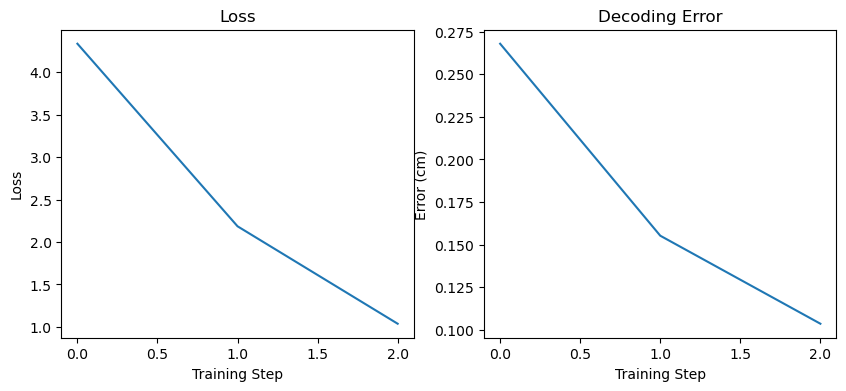

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(trainer.loss)
axes[0].set_title('Loss')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[1].plot(trainer.err)
axes[1].set_title('Decoding Error')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Error (cm)')
plt.show()

torch.Size([5, 20, 1])


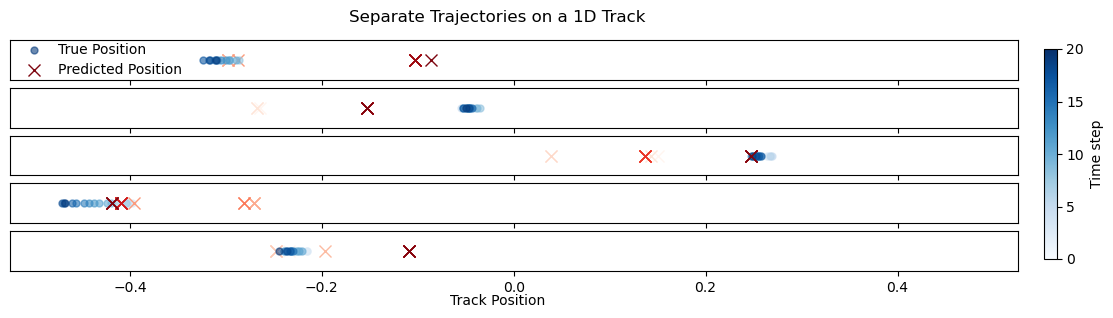

In [44]:
# check if the model generalizes well
inputs, pc_outputs, pos = generator.get_test_batch()
pos = pos.cpu()[:5]
pred_pos = place_cell.get_nearest_cell_pos(trainer.predict(inputs)[0]).cpu()[:5]
print(pred_pos.shape)
centers = place_cell.centers.cpu()
l = options.track_length/2

fig, axes = plt.subplots(5, 1, figsize=(13, 3), sharex=True)

# Colormap for the time points in each trajectory
time_cmap = plt.cm.Blues
test_cmap = plt.cm.Reds

# Normalize the time points for the colormap
norm = plt.Normalize(0, pos.shape[1])

# Plot each trajectory in its own subplot
for i, (ax, traj) in enumerate(zip(axes, pos)):
    for j, point in enumerate(traj):
        ax.plot(traj[j], 0, 'o', color=time_cmap(norm(j)), markersize=5, alpha=0.6)
        ax.plot(pred_pos[i, j], 0, 'x', color=test_cmap(norm(j)), markersize=8)
    
    if i == 0:
        # add a legend
        ax.plot(-l, 0.05, 'o', color=time_cmap(norm(pos.shape[1]-1)), markersize=5, alpha=0.6)
        ax.text(-l+l/20, 0.05, 'True Position', va='center', ha='left')
        ax.plot(-l, -0.05, 'x', color=test_cmap(norm(pos.shape[1]-1)),markersize=8)
        ax.text(-l+l/20, -0.05, 'Predicted Position', va='center', ha='left')

    
    ax.set_xlim(-l-l/20, l+l/20)
    ax.set_ylim(-0.1, 0.1)
    ax.get_yaxis().set_visible(False)  # Hide the y-axis
    # ax.get_xaxis().set_visible(False)  # Hide the x-axis

fig.text(0.5, 0.01, 'Track Position', ha='center', va='center')
fig.suptitle('Separate Trajectories on a 1D Track')

# add a colorbar for the time points
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Time step')

plt.show()

In [45]:
print(pos[0])
print(pred_pos[0])

tensor([[-0.3076],
        [-0.3089],
        [-0.3118],
        [-0.3076],
        [-0.3117],
        [-0.3083],
        [-0.3013],
        [-0.2956],
        [-0.2867],
        [-0.2966],
        [-0.2893],
        [-0.2966],
        [-0.2995],
        [-0.3052],
        [-0.3091],
        [-0.3111],
        [-0.3166],
        [-0.3240],
        [-0.3177],
        [-0.3102]])
tensor([[-0.2980],
        [-0.2980],
        [-0.2980],
        [-0.2980],
        [-0.2980],
        [-0.2980],
        [-0.2980],
        [-0.2879],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.0859]], dtype=torch.float64)


In [46]:
# get grid cell rate maps
def compute_ratemaps(
        model, 
        trainer,
        trajectory_generator,  
        options, 
        res=20, 
        n_avg=None, 
        Ng=512, 
        idxs=None,
    ):
    '''Compute spatial firing fields'''

    g = np.zeros([n_avg, options.batch_size * options.seq_len, Ng])
    pos = np.zeros([n_avg, options.batch_size * options.seq_len, 1])

    activations = np.zeros([Ng, res]) 
    counts  = np.zeros(res)

    for index in range(n_avg):
        # pos_batch: [batch_size, seq_len, 2]
        inputs, _, pos_batch = trajectory_generator.get_test_batch()

        # g_batch = model.g(inputs).detach().cpu().numpy().reshape(-1, Ng) # [seq_len*batch_size, Ng]
        _, g_batch = trainer.predict(inputs)
        g_batch = g_batch.detach().cpu().numpy().reshape(-1, Ng) # [seq_len*batch_size, Ng]
        
        pos_batch = pos_batch.cpu().numpy().reshape(-1, 1) # [seq_len*batch_size, 1]

        # g_batch records the activations of all grid cells across all points in all trajectories in this batch
        g_batch = g_batch.reshape(-1, Ng) # [seq_len*batch_size, Ng]
        
        g[index] = g_batch
        pos[index] = pos_batch

        # Convert position (-1, 1) to indices (0, res)
        pos_batch = (pos_batch + options.track_length/2) / (options.track_length) * res

        for i in range(options.batch_size*options.seq_len):
            x = pos_batch[i, 0]
            if x >=0 and x < res:
                counts[int(x)] += 1
                activations[:, int(x)] += g_batch[i, :]

    # make it a density map
    for k in range(res):
        if counts[k] > 0:
            activations[:, k] /= counts[k]
                
    g = g.reshape([-1, Ng])
    pos = pos.reshape([-1, 1])
    rate_map = activations.reshape(Ng, -1)

    return rate_map

rate_map = compute_ratemaps(model, trainer, generator, options, n_avg=100, res=200, Ng=options.Ng)


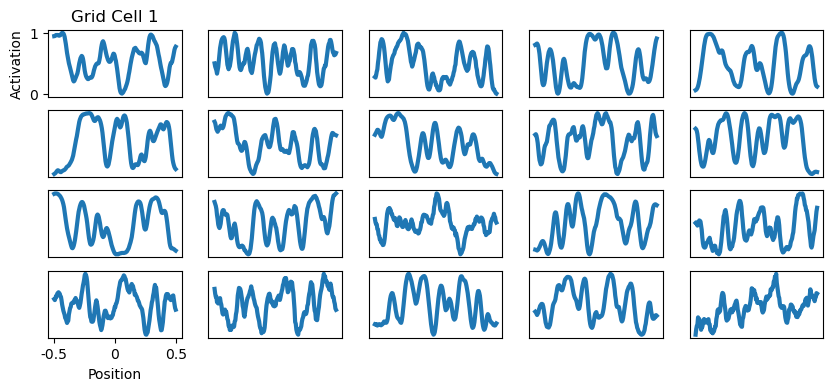

In [47]:
# visualize the rate maps
n_col = 4
fig, ax = plt.subplots(n_col, options.Ng//n_col, figsize=(2*options.Ng//n_col, n_col))
for i, ax in enumerate(ax.flatten()):
    r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
    ax.plot(np.linspace(-options.track_length/2, options.track_length/2, 200), r, lw=3)
    # set overall x and y labels
    if i == 0:
        ax.set_ylabel('Activation')
        ax.set_title(f'Grid Cell {i+1}')
    else:
        ax.get_yaxis().set_visible(False)
        
    if i == options.Ng // n_col * (n_col - 1):
        ax.set_xlabel('Position')
    else:
        ax.get_xaxis().set_visible(False)

    ax.set_xticks([-options.track_length/2, 0, options.track_length/2])
    ax.set_xticklabels([-options.track_length/2, 0, options.track_length/2])
plt.show()